# Brazil's Shrinking New Reserves

Notebook 02 asked how big protected areas are. This asks how that has changed over time. I chose Brazil due to its large natural forests.

**Data.** The same WDPA export as the previous notebook, filtered to areas whose parent country
is Brazil, using the `STATUS_YR` field that records the year of designation.


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from style import use_report_style

use_report_style()

In [2]:
brazil = pd.read_csv(
    "../data/protected_areas.csv",
    usecols=["PRNT_ISO3", "GIS_AREA", "STATUS_YR"],
    low_memory=False,
)
brazil = brazil[brazil["PRNT_ISO3"] == "BRA"]

# STATUS_YR is 0 where the designation year is unrecorded
brazil = brazil[brazil["STATUS_YR"] > 1900].copy()

brazil["Decade"] = (brazil["STATUS_YR"] // 10) * 10
by_decade = brazil[brazil["Decade"].between(1950, 2020)]

print(f"{len(by_decade):,} Brazilian protected areas with a recorded designation year")
by_decade.groupby("Decade")["GIS_AREA"].agg(["count", "median"])

4,054 Brazilian protected areas with a recorded designation year


,count,median
Decade,,
1950,10,24.900804
1960,46,28.750180
1970,45,49.592117
1980,258,106.619507
1990,711,31.692445
2000,1315,31.214206
2010,1015,1.497532
2020,458,0.617440


## Why decades

Individual years give ~60 boxes, making them too thin. Decades give seven groups with enough areas in each for quartiles to be meaningful. That does mean, however, that small-scale changes don't show here.


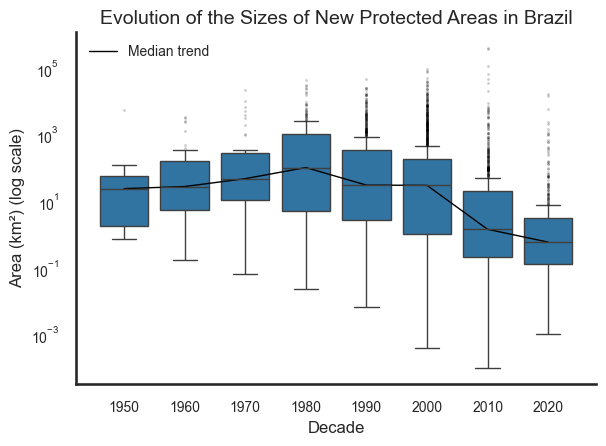

In [3]:
medians = by_decade.groupby("Decade")["GIS_AREA"].median()

sns.set_style("white")
sns.set_context("talk")

sns.boxplot(
    data=by_decade,
    x="Decade",
    y="GIS_AREA",
    flierprops={
        "marker": "o",
        "markersize": 2,
        "markerfacecolor": "black",
        "markeredgecolor": "none",
        "alpha": 0.2,
    },
)

plt.plot(
    range(len(medians)),
    medians.values,
    color="black",
    linewidth=1,
    label="Median trend",
)

plt.yscale("log")
plt.title("Evolution of the Sizes of New Protected Areas in Brazil", fontsize=14)
plt.xlabel("Decade", fontsize=12)
plt.ylabel("Area (km²) (log scale)", fontsize=12)
plt.tick_params(axis="both", which="major", labelsize=10)
plt.tick_params(axis="x", which="major", bottom=False)
plt.legend(loc="upper left", fontsize=10)

sns.despine()
plt.tight_layout()
plt.savefig("../figures/03-protected-area-size-over-time.png", dpi=150, bbox_inches="tight")
plt.show()

## Results

It seems that new protected areas were the largest on average in the 1980’s. The trend line is going downwards, indicating that new protected areas in Brazil are increasingly small. The distributions seem to grow wider. As mentioned in the previous notebook, the shrinkage of new protected areas means more “edge effects” and biodiversity loss. 

More in-depth examination requires data about the overall protected area per country compared to the total area of the country. For that, see [`07-protection-heatmap-clustermap.ipynb`](./07-protection-heatmap-clustermap.ipynb). It shows that less than a third of Brazil is protected, meaning that the decrease in the size of new protected areas isn't due to Brazil having already protected most of its land.

**Design notes:**
I chose to keep the trend line thin and black in order to keep the median lines visible and to not distract too much from the boxes. Fliers are necessary due to the large width of the distributions. As with the previous notebook, flier overplotting was a problem. Again, it was solved by decreasing the sizes and alpha values of the fliers. This time, a simple box plot was enough to visualize the data in an intuitive way. Y-axis needed a logarithmic scale due to the large distribution.
